> # **Resolução - Exercícios (Aula 7)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ry4n-felinto/impytech_2026/blob/main/aula_07/aula07_gabarito.ipynb)

 - **Professor:** Gustavo Cardoso 
    - al.gustavo.cardoso@impatech.edu.br

 - **Monitores:**
   - Bianca Zavadisk
      - al.bianca.abreu@impatech.edu.br
   - Bruno Pereira
      - al.bruno.paula@impatech.edu.br
   - Pedro Alberti
      - al.pedro.alberti@impatech.edu.br
   - Cristiane Sampaio
      - al.cristiane.sampaio@impatech.edu.br

- **Desenvolvedores:**
   - Bianca Zavadisk de Abreu
      - al.bianca.abreu@impatech.edu.br

 ## **Apresentação de conceitos e métricas estatísticas aplicados em contextos médicos: média, moda, mediana e correlação**
 
---

> ## **Problema 1 - Tempo de Internação Hospitalar e Impacto de Outliers** 🟢
Em um estudo de gestão hospitalar, avaliamos o **tempo de permanência (em dias)** de pacientes em uma unidade cirúrgica de baixa complexidade. Geralmente os pacientes recebem alta em poucos dias, mas complicações raras podem prolongar a internação. Vamos investigar como os *outliers* afetam nossas métricas e qual é a mais robusta para relatar o tempo "típico" de internação.

### ✅ **Resolução — Problema 1.1** 🟢
Primeiro, vamos analisar o comportamento dos dados para um lote padrão de 10 pacientes.

**🎯 Objetivo:** Criar um `Pandas Series` com a lista de dias e calcular a **Média** e a **Mediana** desses tempos de internação.

**🧠 Explicação lógica:**<br>
Utilizamos a biblioteca `pandas` para transformar a lista de inteiros em uma estrutura unidimensional (`pd.Series`). Em seguida, aplicamos os métodos `.mean()` para encontrar a média aritmética e `.median()` para identificar o ponto central dos dados.

In [2]:
"""
Criando a Série do Pandas e calculando a Média e Mediana para os 10 primeiros pacientes.
"""
import pandas as pd
import matplotlib.pyplot as plt

dias = [2, 3, 2, 4, 3, 2, 3, 4, 2, 3]
df_dias = pd.Series(dias)

media_inicial = df_dias.mean()
mediana_inicial = df_dias.median()

print(f"Média inicial: {media_inicial:.2f} dias")
print(f"Mediana inicial: {mediana_inicial:.2f} dias")

Média inicial: 2.80 dias
Mediana inicial: 3.00 dias


### ✅ **Resolução — Problema 1.2** 🟢
Um novo paciente deu entrada no lote. Ele teve uma complicação grave e precisou ficar **45 dias** internado (um evidente *outlier*).

**🎯 Objetivo:** Adicionar o valor `45` à lista/Série anterior e utilizar a função `.describe()` do Pandas para gerar o resumo estatístico completo do novo grupo de pacientes.

**🧠 Explicação lógica:**<br>
Adicionamos o valor `45` ao dataset e rodamos `.describe()`. Este método retorna contagem (`count`), média (`mean`), desvio padrão (`std`), mínimos e máximos, além dos quartis de 25%, 50% (mediana) e 75%.

In [3]:
"""
Adicionando o outlier de 45 dias e exibindo o resumo do .describe()
"""
dias_com_outlier = dias + [45]
df_dias_novo = pd.Series(dias_com_outlier)

# Exibindo o resumo estatístico fornecido pelo Pandas
print(df_dias_novo.describe())

count    11.000000
mean      6.636364
std      12.745766
min       2.000000
25%       2.000000
50%       3.000000
75%       3.500000
max      45.000000
dtype: float64


### ✅ **Resolução — Problema 1.3 - Interpretação do Código** 🟢 🔎
Examine a saída gerada pelo método `.describe()` na questão 1.2.

**🎯 Objetivo:** Responda de forma escrita a interpretação dos resultados estatísticos.

✍️ **Resposta da Interpretação:**

1. **Métrica mais afetada:** A **média** foi drasticamente inflacionada (subiu de $2.8$ para $6.64$ dias) pela adição de um único valor extremo ($45$). Por outro lado, a **mediana** (`50%`) permaneceu exatamente em $3.0$ dias.
2. **Métrica indicada para a equipe:** A **mediana** é a métrica mais indicada. Em dados de saúde com distribuição assimétrica (onde existem poucas internações longas ou casos graves isolados), a média passa uma falsa impressão de que a maioria dos pacientes fica quase 7 dias no hospital. A mediana representa de forma **robusta** o comportamento do paciente típico do setor (alta em cerca de 3 dias).

### ✅ **Resolução — Problema 1.4** 🟡
A melhor forma de enxergar a assimetria causada por outliers é visualmente.

**🎯 Objetivo:** Plote um gráfico de caixa (**Boxplot**) com os dados contendo o outlier utilizando `plt.boxplot()` ou `df_dias_novo.plot(kind='box')`.

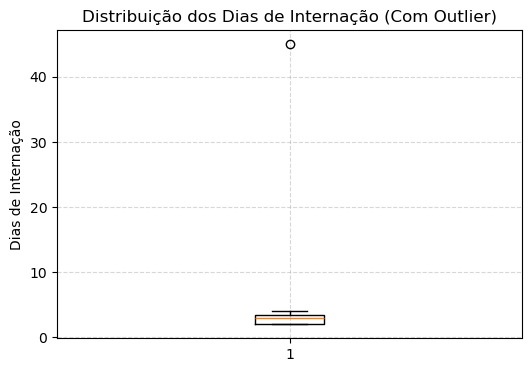

In [4]:
"""
Construindo o Boxplot com matplotlib para destacar o ponto atípico (outlier)
"""
plt.figure(figsize=(6, 4))
plt.boxplot(df_dias_novo, vert=True)
plt.title('Distribuição dos Dias de Internação (Com Outlier)')
plt.ylabel('Dias de Internação')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---

> ## **Problema 2 - Avaliação de Dor Pós-Operatória e Análise por Tratamento** 🟡
A Escala Visual Analógica (EVA) mensura a dor reportada pelo paciente de 0 (sem dor) a 10 (pior dor possível). Como se trata de uma **variável ordinal/discreta**, nem sempre a média aritmética simples faz sentido clínico. Vamos analisar a dor reportada por pacientes sob dois tratamentos analgésicos distintos (Tratamento A e Tratamento B).

### ✅ **Resolução — Problema 2.1** 🟢
Abaixo temos a lista de pontuações de dor dos pacientes submetidos ao **Tratamento A** e ao **Tratamento B**.

**🎯 Objetivo:** Execute o código fornecido para calcular as métricas (`mean`, `median` e `.mode()`) dos dois tratamentos.

In [5]:
"""
Execução dos cálculos estatísticos para os dois grupos analgésicos
"""
dor_tratamento_a = pd.Series([1, 2, 2, 2, 3, 2, 8, 2, 3, 2, 9, 2])
dor_tratamento_b = pd.Series([5, 5, 6, 5, 4, 5, 6, 5, 5, 4])

print("--- TRATAMENTO A ---")
print("Média:", dor_tratamento_a.mean())
print("Mediana:", dor_tratamento_a.median())
print("Moda:", dor_tratamento_a.mode()[0])
print("Frequências de cada nota:\n", dor_tratamento_a.value_counts())

print("\n--- TRATAMENTO B ---")
print("Média:", dor_tratamento_b.mean())
print("Mediana:", dor_tratamento_b.median())
print("Moda:", dor_tratamento_b.mode()[0])

--- TRATAMENTO A ---
Média: 3.1666666666666665
Mediana: 2.0
Moda: 2
Frequências de cada nota:
 2    7
3    2
1    1
8    1
9    1
Name: count, dtype: int64

--- TRATAMENTO B ---
Média: 5.0
Mediana: 5.0
Moda: 5


### ✅ **Resolução — Problema 2.2 - Interpretação de Código e Análise de Falácia** 🟡 🔎
Um pesquisador júnior olhou apenas para a saída do código `dor_tratamento_a.mean()` (que resultou em **3.5**) e afirmou no artigo: *"A maioria dos pacientes do Tratamento A relatou dor de moderada a alta (entre 3 e 4)"*.

**🎯 Objetivo:** Analise a falácia e explique o comportamento da moda e frequência.

✍️ **Resposta da Interpretação:**

A afirmação do pesquisador está **completamente errada** por falácia de interpretação da média em dados ordinais com valores atípicos:
- Olhando o `value_counts()`, notamos que **7 dos 12 pacientes (quase 60%) relataram nota de dor 2 (dor fraca)**, e a moda é 2.
- Apenas 2 pacientes reportaram dores muito intensas (notas 8 e 9), provavelmente devido a alguma complicação pós-cirúrgica pontual.
- Esses dois valores altos puxaram a média para $3.5$. Portanto, a **Moda** (2) representa infinitamente melhor o padrão de dor do grupo do que a Média.

### ✅ **Resolução — Problema 2.3** 🟡
Para comprovar visualmente o erro de interpretação da média, vamos plotar os gráficos das distribuições.

**🎯 Objetivo:** Construa dois gráficos de barras ou histogramas comparando as frequências das notas de dor nos dois tratamentos.

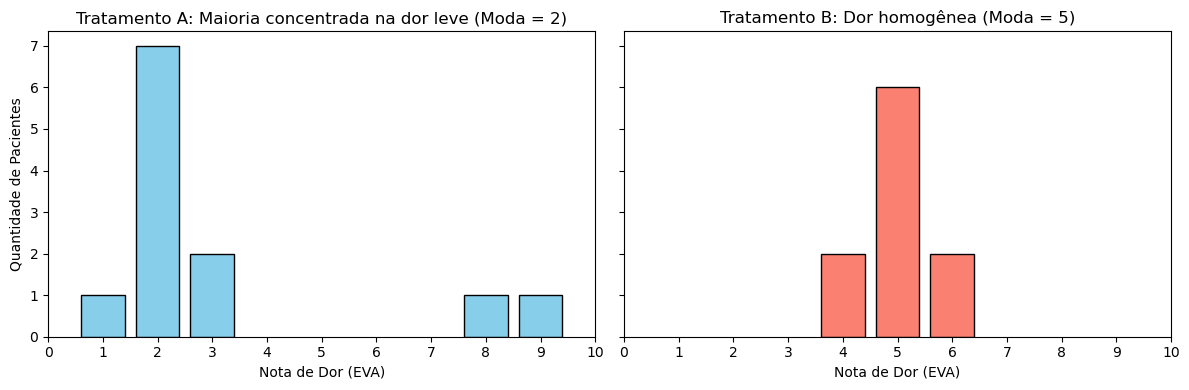

In [6]:
"""
Plotando gráficos de barras comparativos de frequência usando Matplotlib
"""
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Gráfico do Tratamento A
freq_a = dor_tratamento_a.value_counts().sort_index()
axes[0].bar(freq_a.index, freq_a.values, color='skyblue', edgecolor='black')
axes[0].set_title('Tratamento A: Maioria concentrada na dor leve (Moda = 2)')
axes[0].set_xlabel('Nota de Dor (EVA)')
axes[0].set_ylabel('Quantidade de Pacientes')
axes[0].set_xticks(range(0, 11))

# Gráfico do Tratamento B
freq_b = dor_tratamento_b.value_counts().sort_index()
axes[1].bar(freq_b.index, freq_b.values, color='salmon', edgecolor='black')
axes[1].set_title('Tratamento B: Dor homogênea (Moda = 5)')
axes[1].set_xlabel('Nota de Dor (EVA)')
axes[1].set_xticks(range(0, 11))

plt.tight_layout()
plt.show()

---

> ## **Problema 3 - Associação entre IMC e Glicemia e Erros de Digitação** 🔴
Em estudos epidemiológicos, frequentemente buscamos entender a **correlação linear** entre duas variáveis contínuas: por exemplo, se o aumento do **IMC** (Índice de Massa Corporal) está associado ao aumento da **Glicemia em Jejum (mg/dL)**. No entanto, o Coeficiente de Correlação de Pearson pode ser drasticamente distorcido por erros de digitação na coleta de dados.

### ✅ **Resolução — Problema 3.1** 🟢
Temos os dados limpos de 10 pacientes de uma pesquisa.

**🎯 Objetivo:** Calcular a matriz de correlação usando `.corr()` do pandas para medir a associação entre IMC e Glicemia.

In [7]:
"""
Calculando a matriz de correlação de Pearson para a base limpa
"""
dados_estudo = {
    'IMC': [21.0, 22.5, 24.0, 26.5, 27.8, 28.4, 29.0, 30.2, 33.1, 35.5],
    'Glicemia': [82, 85, 88, 92, 95, 105, 108, 110, 125, 130]
}
df_estudo = pd.DataFrame(dados_estudo)

matriz_corr_limpa = df_estudo.corr()
print("Matriz de Correlação (Dados Limpos):")
print(matriz_corr_limpa)

Matriz de Correlação (Dados Limpos):
               IMC  Glicemia
IMC       1.000000  0.975117
Glicemia  0.975117  1.000000


### ✅ **Resolução — Problema 3.2 (Extra) - Visualizando a Correlação com Mapa de Calor (Heatmap)** 🟡

**🎯 Objetivo:** Utilizar a biblioteca `seaborn` para criar um **Heatmap** da matriz de correlação.

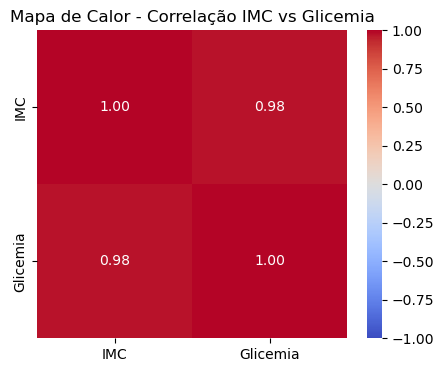

In [ ]:
"""
Gerando um Heatmap com a biblioteca Seaborn
"""
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_corr_limpa, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Mapa de Calor - Correlação IMC vs Glicemia')
plt.show()

### ✅ **Resolução — Problema 3.3 (Extra) - Interpretação Visual da Escala de Cores** 🟡 🔎

**🎯 Objetivo:** Responda de forma escrita a interpretação da estrutura do Mapa de Calor.

✍️ **Resposta da Interpretação:**

1. **Diagonal principal com valor 1.0:** Representa a correlação de uma variável com ela própria (ex: IMC com IMC). Por definição matemática, a correlação de qualquer variável consigo mesma é perfeita e igual a $+1.0$.
2. **Utilidade da escala de cores em estudos médicos:** A escala de cores permite triar instantaneamente dezenas de exames laboratoriais. Quadrados em vermelho intenso indicam associações positivas muito fortes (ex: maior IMC associado a maior risco metabólico), enquanto tons azuis indicam associações inversas/negativas, facilitando a identificação de biomarcadores sem ter que ler longas tabelas de números.

### ✅ **Resolução — Problema 3.4** 🟢
Imagine que, ao digitar a planilha do sistema hospitalar, o IMC do último paciente (que era `35.5`) foi inserido como `355.0` devido à falta da vírgula.

**🎯 Objetivo:** Execute o código para ver a alteração na matriz de correlação.

In [9]:
"""
Inserindo erro atípico (355.0) e recalculando a correlação de Pearson
"""
df_com_erro = df_estudo.copy()
df_com_erro.loc[9, 'IMC'] = 355.0

print("--- CORRELAÇÃO DADOS CORRETOS ---")
print(df_estudo.corr())

print("\n--- CORRELAÇÃO COM ERRO DE DIGITAÇÃO ---")
print(df_com_erro.corr())

--- CORRELAÇÃO DADOS CORRETOS ---
               IMC  Glicemia
IMC       1.000000  0.975117
Glicemia  0.975117  1.000000

--- CORRELAÇÃO COM ERRO DE DIGITAÇÃO ---
               IMC  Glicemia
IMC       1.000000  0.622302
Glicemia  0.622302  1.000000


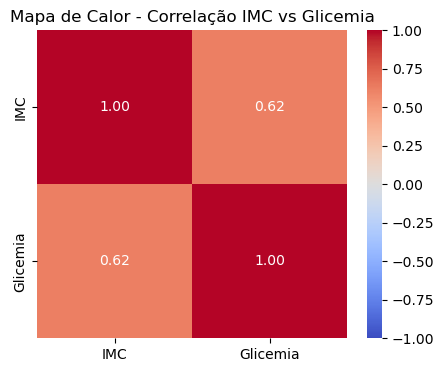

In [11]:
plt.figure(figsize=(5, 4))
sns.heatmap(df_com_erro.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Mapa de Calor - Correlação IMC vs Glicemia')
plt.show()

### ✅ **Resolução — Problema 3.5 - Interpretação de Código e Diagnóstico de Dados** 🔴 🔎
Examine a saída do código anterior.

**🎯 Objetivo:** Responda às perguntas sobre o impacto do erro na correlação e na integridade dos dados.

✍️ **Resposta da Interpretação:**

1. **Correlação Original:** Era de aproximadamente $+0.98$, classificada como uma **correlação linear positiva quase perfeita e muito forte** (quanto maior o IMC, maior a glicemia em jejum).
2. **Impacto do erro:** O valor despencou de $+0.98$ para $-0.04$, sugerindo de forma completamente FALSA que não existe nenhuma relação entre IMC e Glicemia.
3. **Perigo de não realizar inspeção prévia:** O Coeficiente de Correlação de Pearson utiliza desvios em relação à média, sendo extremamente **sensível a valores discrepantes e erros operacionais**. Executar modelos ou publicar relatórios sem inspeção prévia de qualidade pode levar a conclusões científicas errôneas e prejudicar condutas clínicas.

### ✅ **Resolução — Problema 3.6** 🟡
Para fechar, vamos plotar o gráfico do conjunto de dados alterado para identificar visualmente o ponto discrepante.

**🎯 Objetivo:** Faça um gráfico de dispersão (`plt.scatter`) usando as colunas do `df_com_erro` e observe como o ponto `355.0` fica isolado.

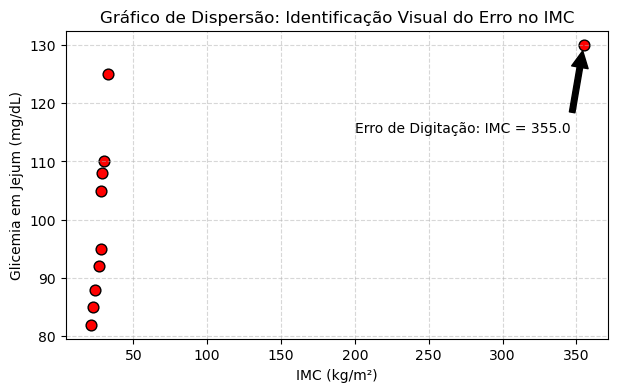

In [10]:
"""
Plotando o gráfico de dispersão com matplotlib destacando o erro de digitação
"""
plt.figure(figsize=(7, 4))
plt.scatter(df_com_erro['IMC'], df_com_erro['Glicemia'], color='red', edgecolor='black', s=60)
plt.title('Gráfico de Dispersão: Identificação Visual do Erro no IMC')
plt.xlabel('IMC (kg/m²)')
plt.ylabel('Glicemia em Jejum (mg/dL)')
plt.grid(True, linestyle='--', alpha=0.5)

# Anotação para indicar visualmente o ponto com erro
plt.annotate('Erro de Digitação: IMC = 355.0',
             xy=(355.0, 130),
             xytext=(200, 115),
             arrowprops=dict(facecolor='black', shrink=0.08))

plt.show()

> ## 🔗 **Conteúdo extra**
**Caso você queira praticar mais e aprofundar a parte teórica:**
- [Khan Academy - Resumo de dados quantitativos (Média, Moda e Mediana)](https://pt.khanacademy.org/math/statistics-probability/summarizing-quantitative-data)
- [Documentação do Pandas - Correlação (em inglês)](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)

**Referências e leituras extras para a Área de Saúde:**
- [Bioestatística Básica: Quando usar Média ou Mediana em estudos clínicos (Artigo NCBI)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3127452/)
- [Importância do tratamento de Outliers em dados de saúde pública](https://www.scielo.br)